# Final Assignment - Computational Macroeconomics
### Student: Binyam Yohannes Olango
### ID: 4767382
### Date: 03 Aug 2026

---

## Overview
This notebook contains my full solutions to the Final Assignment.  
All notations and formulas follows the assignment sheet.


In [1]:
# Importing packages needed for the tasks
import numpy as np
from scipy.optimize import fsolve
import matplotlib.pyplot as plt
%matplotlib inline


## Task 1


In [2]:
# Defining parameters
sigma= 1
kappa=0.3
beta=0.995
phi_pi=1.5
phi_y=0.1
rho_mu=0.7


def model(z_t, Ez_t1, z_tm1, u_t):
    """
    Computes the residuals of the model equation: A z_t = M E_t[z_{t+1}] + D z_{t-1} + u_t

    Inputs:
    z_t: vector of current-period variables [mu_t, y_t, pi_t, i_t]
    Ez_t1: vector of expected next-period variables E_t[z_{t+1}]
    z_tm1: vector of lagged variables z_{t-1}
    u_t: vector of shocks

    Return: vector of residuals.
    """

    # Contribution of current-period variables
    left = A @ z_t

    # Contribution of expected future variables, lagged variables, and shocks
    right = M @ Ez_t1 + D @ z_tm1 + u_t

    # Residuals: must be zero for the model to hold
    return left - right

# Writing Matrix A which contains the coefficients on current-period variables
A = np.array([
    [1, 0, 0, 0],
    [0, 1, 0, 1/sigma],
    [-1, -kappa, 1, 0],
    [0, 0, 0, 1]
], dtype=float)

# Writing Matrix M which contains the coefficients on expected future variables
M = np.array([
    [0, 0, 0, 0],
    [0, 1, 1/sigma, 0],
    [0, 0, beta, 0],
    [0, 0, 0, 0]
], dtype=float)

# Writing Matrix D which contains the coefficients on lagged variables
D = np.array([
    [rho_mu, 0, 0, 0],
    [0, 0, 0, 0],
    [0, 0, 0, 0],
    [0, phi_y, phi_pi, 0]
], dtype=float)


## Task 2

In [3]:
def steady_state(z_guess):
    """
    In steady state: z_t = E_t[z_{t+1}] = z_{t-1} = z_guess, shocks (u_t) = 0

    Input: z_guess - a vector that containing trial values for these four variables: [mu, Y, pi, i]
    
    Return: The difference of implied z_t and z_guessed steady state values
    """
    
    # Creating a NumPy array from the input z_guess
    z_guess = np.array(z_guess, dtype=float)

    
    # With the above assumption calculate the right and left hand side of Equation 6 from the sheet separately
    right = M @ z_guess + D @ z_guess
    left = A @ z_guess

    return left - right

## Task 3


In [4]:
# Create an initial guess for the state vector.
# np.zeros(4) creates a NumPy array with elements value 0
z0 = np.zeros(4)

# fsolve attempts to find values of z such that: steady_state(z) = [0, 0, 0, 0]
z_ss = fsolve(steady_state, z0)


Because the steady state of the model is exactly zero, the MSV solution does not need a constant term. A constant term would only be required if the model converged to a non‑zero steady state. Since fsolve shows that all steady‑state values are zero, the MSV solution can be written entirely as a linear function of lagged variables and shocks, with no additional constant needed to shift the solution.

## Task 4

In [5]:
def LTI(A, M, D, F_guess):
    """
    Applies the Linear Time Iteration (LTI) algorithm to compute
    the matrices F and Q in the MSV solution:  z_t = F z_{t-1} + Q u_t

    Inputs:
    A, M, D = model matrices from Task 1
    F_guess = initial guess for F

    Return:
    F_new = matrix of coefficients on lagged variables
    Q = matrix of coefficients on shocks
    """

    # F_new = (A - M F_guess)^(-1) * D
    F_new = np.linalg.inv(A - M @ F_guess) @ D

    # Q = (A - M F_new)^(-1)
    Q = np.linalg.inv(A - M @ F_new)

    return F_new, Q


## Task 5

In [6]:
def solve_LTI(A, M, D, tol=1e-10, max_iter=500):
    """
    Repeatedly calls the LTI algorithm until F converges.
    
    Inputs:
    A, M, D      → model matrices from task 1
    tol          → convergence tolerance (how close F_new must be to F_old)
    max_iter     → maximum number of iterations allowed
    
    Returns:
    F            → converged matrix of coefficients on lagged variables
    Q            → matrix of coefficients on shocks
    """

    # Step 1: Start with an initial guess for F and Q (zero matrix is standard)
    F_old = np.zeros_like(A)
    Q = np.zeros_like(A)  # initial value

    # Step 2: Iterate the LTI update until convergence
    for iteration in range(max_iter):

        # Call the LTI function from Task 4
        F_new, Q = LTI(A, M, D, F_old)

        # Step 3: Check convergence
        # If the difference between F_new and F_old is tiny, we stop
        if np.max(np.abs(F_new - F_old)) < tol:
            print(f"Converged after {iteration+1} iterations.")
            return F_new, Q

        # Step 4: Update F_old for the next iteration
        F_old = F_new

    # If we reach max_iter without converging, warn the user
    print("Warning: LTI did not converge within max_iter.")
    return F_old, Q


## Task 6


In [7]:
# Calling the solve_LTI function to get the F and Q
F, Q = solve_LTI(A, M, D)

# Columns of F correspond to lagged state variables [mu_{t-1}, y_{t-1}, pi_{t-1}, i_{t-1}]
C_mu   = F[:, 0]
C_y    = F[:, 1]
C_pi   = F[:, 2]

# Columns of Q correspond to components of shocks vector u_t = [eps_mu, 0, 0, eps_i]
C_eps_mu = Q[:, 0]
C_eps_i  = Q[:, 3]


Converged after 37 iterations.


## Task 7

In [8]:
# Impulse responses to a one-time shock to eps_mu_t

T = 30  # number of periods for the Impulse Response Function

# Arrays to store the paths of mu, Y, pi, i
mu_path_mu = np.zeros(T)
Y_path_mu  = np.zeros(T)
pi_path_mu = np.zeros(T)
i_path_mu  = np.zeros(T)

# Initial state at t = -1 (before the shock): all variables (mu, Y, pi, i) at steady state (zero)
z_tm1 = np.zeros(4)

# Size of the one-time shock to eps_mu_t at t = 0
eps_mu_t = 0.01

for t in range(T):
    if t == 0:
        # At t = 0: one-time shock to eps_mu_t, no shock to eps_i_t
        # u_t = [eps_mu_t, 0, 0, eps_i_t], we got this shocks vector by deriving from the model equation
        u_t = np.array([eps_mu_t, 0.0, 0.0, 0.0])
    else:
        # After t = 0: no more shocks
        u_t = np.zeros(4)

    # Apply MSV solution: z_t = C_mu*mu_{t-1} + C_y*y_{t-1} + C_pi*pi_{t-1} + C_eps_mu*eps_mu_t + C_eps_i*eps_i_t
    z_t = (
        C_mu * z_tm1[0]
        + C_y * z_tm1[1]
        + C_pi * z_tm1[2]
        + C_eps_mu * u_t[0]
        + C_eps_i * u_t[3]
    )

    # Store each variable's path
    mu_path_mu[t] = z_t[0]
    Y_path_mu[t]  = z_t[1]
    pi_path_mu[t] = z_t[2]
    i_path_mu[t]  = z_t[3]

    # Update lagged state for next period
    z_tm1 = z_t

print('First 5 periods of the impulse responses to a 0.01 shock to eps_mu_t:')
print(np.column_stack([mu_path_mu, Y_path_mu, pi_path_mu, i_path_mu])[:5])


First 5 periods of the impulse responses to a 0.01 shock to eps_mu_t:
[[ 0.01       -0.01601607  0.00995374  0.        ]
 [ 0.007      -0.02079855  0.00478248  0.01332901]
 [ 0.0049     -0.01151179  0.00404225  0.00509386]
 [ 0.00343    -0.00902676  0.00260883  0.0049122 ]
 [ 0.002401   -0.00601091  0.00189634  0.00301057]]


## Task 8

In [9]:
# Impulse responses to a one-time shock to eps_i_t

T = 30  # number of periods for the Impulse Response Function

# Arrays to store the paths of mu, Y, pi, i
mu_path_i = np.zeros(T)
Y_path_i  = np.zeros(T)
pi_path_i = np.zeros(T)
i_path_i  = np.zeros(T)

# Initial state at t = -1 (before the shock): all variables at steady state (zero)
z_tm1 = np.zeros(4)

# Size of the one-time shock to eps_i_t at t = 0
eps_i_t = 0.01

for t in range(T):
    if t == 0:
        # At t = 0: one-time shock to eps_i_t, no shock to eps_mu_t
        u_t = np.array([0.0, 0.0, 0.0, eps_i_t])
    else:
        # After t = 0: no more shocks
        u_t = np.zeros(4)

    # Apply the MSV solution using the vectors C_mu, C_y, C_pi, C_eps_mu and C_eps_i
    z_t = (
        C_mu * z_tm1[0]
        + C_y * z_tm1[1]
        + C_pi * z_tm1[2]
        + C_eps_mu * u_t[0]
        + C_eps_i * u_t[3]
    )

    # Store each variable's path
    mu_path_i[t] = z_t[0]
    Y_path_i[t]  = z_t[1]
    pi_path_i[t] = z_t[2]
    i_path_i[t]  = z_t[3]

    # Update lagged state for next period
    z_tm1 = z_t

print('First 5 periods of the impulse responses to a 0.01 shock to eps_i_t:')
print(np.column_stack([mu_path_i, Y_path_i, pi_path_i, i_path_i])[:5])


First 5 periods of the impulse responses to a 0.01 shock to eps_i_t:
[[ 4.91748627e-19 -7.19280614e-03 -1.63938939e-03  1.00000000e-02]
 [ 4.48421138e-19  2.28613612e-03  5.21057738e-04 -3.17836470e-03]
 [ 2.80777158e-19 -7.26617435e-04 -1.65611153e-04  1.01020022e-03]
 [ 2.07070004e-19  2.30945521e-04  5.26372642e-05 -3.21078472e-04]
 [ 1.41603458e-19 -7.34029092e-05 -1.67300423e-05  1.02050448e-04]]


## Task 9

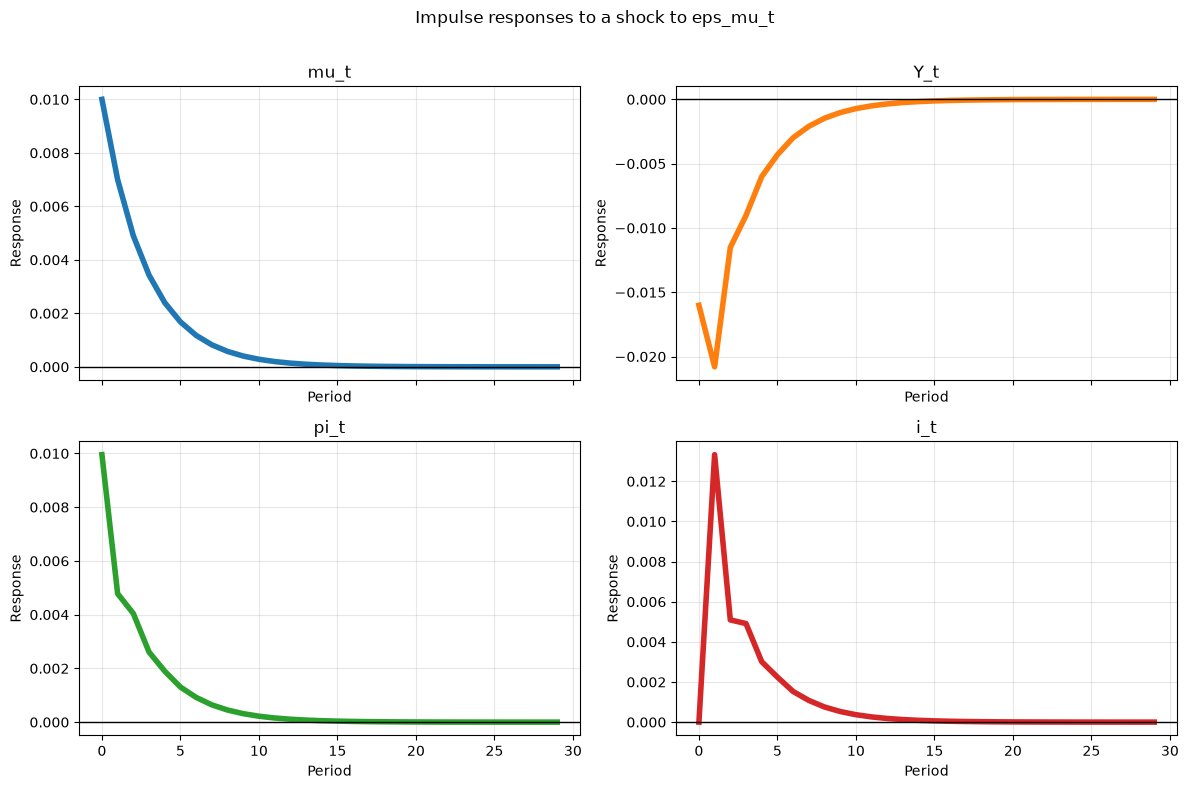

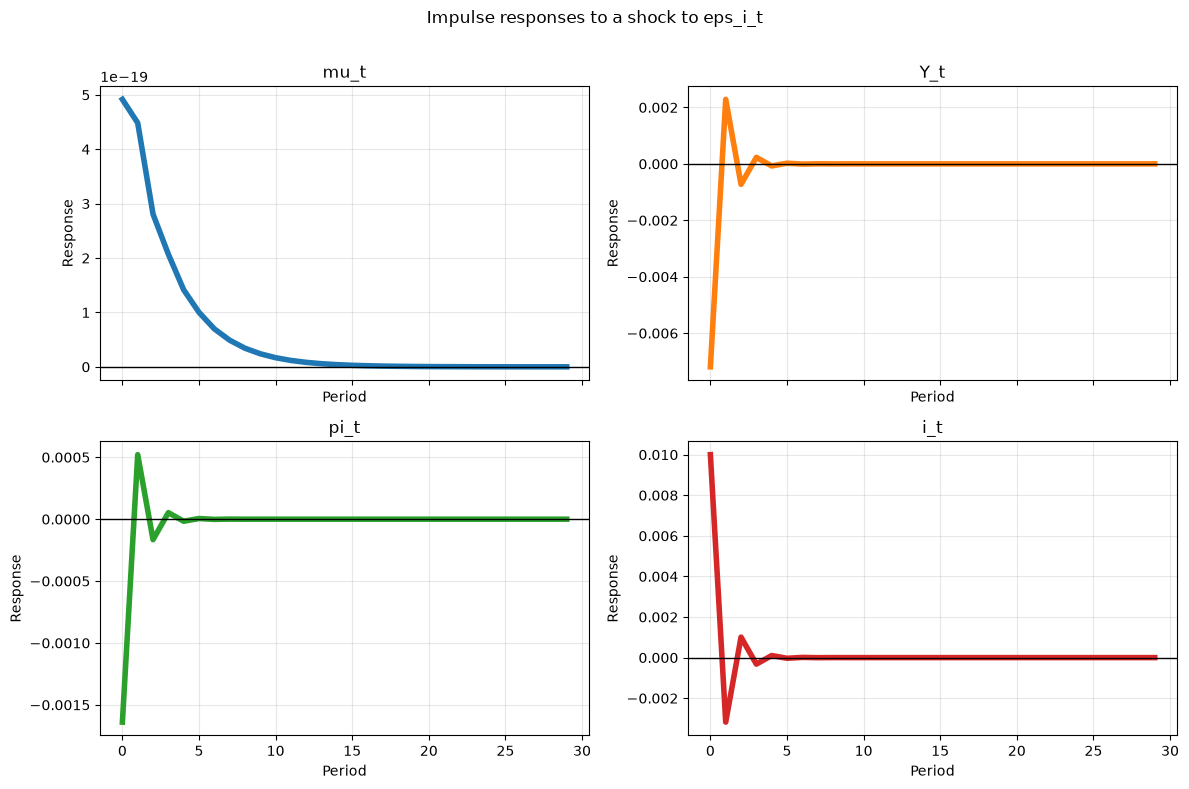

In [10]:
# Create a color list for the four subfigures
colors = ["C0", "C1", "C2", "C3"]

# Plot the impulse responses to a one-time shock to eps_mu_t
# Create a time index for the 30 periods of the IRF
periods = np.arange(T)

# Create a figure with four subfigures, one for each variable in z_t
fig_mu, axes_mu = plt.subplots(2, 2, figsize=(12, 8), sharex=True)

# Store the four variables of the state vector in a list for plotting
variables_mu = [
    ("mu_t", mu_path_mu),
    ("Y_t", Y_path_mu),
    ("pi_t", pi_path_mu),
    ("i_t", i_path_mu),
]

# Plot each variable in its own subplot
for ax, (name, path), color in zip(axes_mu.flatten(), variables_mu, colors):
    ax.plot(periods, path, color=color, linewidth=4)
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(f"{name}")
    ax.set_xlabel("Period")
    ax.set_ylabel("Response")
    ax.grid(True, alpha=0.3)

# Add a title to the full figure and adjust the layout
fig_mu.suptitle("Impulse responses to a shock to eps_mu_t", fontsize=12)
fig_mu.tight_layout(rect=(0, 0, 1, 0.97))

# Plot the impulse responses to a one-time shock to eps_i_t
periods = np.arange(T)

# Create a figure with four subfigures, one for each variable in z_t
fig_i, axes_i = plt.subplots(2, 2, figsize=(12, 8), sharex=True)

# Store the four variables of the state vector in a list for plotting
variables_i = [
    ("mu_t", mu_path_i),
    ("Y_t", Y_path_i),
    ("pi_t", pi_path_i),
    ("i_t", i_path_i),
]

# Plot each variable in its own subplot
for ax, (name, path), color in zip(axes_i.flatten(), variables_i, colors):
    ax.plot(periods, path, color=color, linewidth=4)
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(f"{name}")
    ax.set_xlabel("Period")
    ax.set_ylabel("Response")
    ax.grid(True, alpha=0.3)

# Add a title to the full figure and adjust the layout
fig_i.suptitle("Impulse responses to a shock to eps_i_t", fontsize=12)
fig_i.tight_layout(rect=(0, 0, 1, 0.97))

# Display both figures
plt.show()


## Task 10


In [11]:
# Interpret the impulse responses from Task 9\n# We use simple diagnostics from the simulated IRFs to support the intuition.\nmax_mu_response_mu = np.max(np.abs(mu_path_mu))\nmax_mu_response_i  = np.max(np.abs(mu_path_i))\nmax_i_response_mu  = np.max(np.abs(i_path_mu))\nmax_i_response_i   = np.max(np.abs(i_path_i))\n\nprint('Task 10 interpretation:')\nprint('- A positive inflation shock eps_mu raises current inflation directly, which then affects output and the policy rate through the NKPC and Taylor rule.')\nprint('- Because mu_t follows an AR(1) process, the responses are persistent and decay gradually back to steady state.')\nprint('- A policy shock eps_i moves the nominal interest rate on impact and affects output/inflation indirectly via the IS equation.')\nprint('- The eps_i shock itself is white noise, but endogenous variables do not jump back immediately because lagged mu, y, and pi enter the state and propagate dynamics.')\nprint('- Therefore, responses to eps_mu are typically more persistent than responses to eps_i.')\n\nprint('\\nDiagnostics from your IRFs:')\nprint(f'max |mu_t| after eps_mu shock: {max_mu_response_mu:.6f}')\nprint(f'max |mu_t| after eps_i shock : {max_mu_response_i:.6f}')\nprint(f'max |i_t| after eps_mu shock : {max_i_response_mu:.6f}')\nprint(f'max |i_t| after eps_i shock  : {max_i_response_i:.6f}')\n

## Task 11

In [12]:
# Simulate 500 periods of the model with random shocks\nimport pandas as pd\n\nT_sim = 500\nnp.random.seed(42)\n\n# Standard deviations for white-noise shocks\nsigma_eps_mu = 0.01\nsigma_eps_i = 0.01\n\n# Draw random shocks\neps_mu_sim = np.random.normal(loc=0.0, scale=sigma_eps_mu, size=T_sim)\neps_i_sim = np.random.normal(loc=0.0, scale=sigma_eps_i, size=T_sim)\n\n# Allocate arrays for simulated time series\nmu_sim = np.zeros(T_sim)\nY_sim = np.zeros(T_sim)\npi_sim = np.zeros(T_sim)\ni_sim = np.zeros(T_sim)\n\n# Initial state at steady state\nz_tm1 = np.zeros(4)\n\nfor t in range(T_sim):\n    # Build the shock vector u_t = [eps_mu_t, 0, 0, eps_i_t]\n    u_t = np.array([eps_mu_sim[t], 0.0, 0.0, eps_i_sim[t]])\n\n    # MSV representation using vectors from Task 6\n    z_t = (\n        C_mu * z_tm1[0]\n        + C_y * z_tm1[1]\n        + C_pi * z_tm1[2]\n        + C_eps_mu * u_t[0]\n        + C_eps_i * u_t[3]\n    )\n\n    mu_sim[t] = z_t[0]\n    Y_sim[t] = z_t[1]\n    pi_sim[t] = z_t[2]\n    i_sim[t] = z_t[3]\n\n    z_tm1 = z_t\n\n# DataFrame requested in Task 11\nsim_df = pd.DataFrame({\n    'mu_t': mu_sim,\n    'Y_t': Y_sim,\n    'pi_t': pi_sim,\n    'i_t': i_sim,\n    'eps_mu_t': eps_mu_sim,\n    'eps_i_t': eps_i_sim\n})\n\nprint('Task 11: first 5 rows of simulated series')\nprint(sim_df.head())\n

## Task 12


In [13]:
# Calculate E_t[pi_{t+1}] from the 1-period-forwarded MSV solution\n# z_{t+1} = C_mu*mu_t + C_y*Y_t + C_pi*pi_t + C_eps_mu*eps_mu_{t+1} + C_eps_i*eps_i_{t+1}\n# With white-noise shocks, E_t[eps_mu_{t+1}] = E_t[eps_i_{t+1}] = 0.\n\nE_pi_tplus1 = (\n    C_mu[2] * sim_df['mu_t'].to_numpy()\n    + C_y[2] * sim_df['Y_t'].to_numpy()\n    + C_pi[2] * sim_df['pi_t'].to_numpy()\n)\n\nsim_df['E_t_pi_tplus1'] = E_pi_tplus1\n\nprint('Task 12: added E_t_pi_tplus1 column')\nprint(sim_df[['pi_t', 'E_t_pi_tplus1']].head())\n

## Task 13

In [14]:
# Forecast error: pi_{t+1} - E_t[pi_{t+1}]\nsim_df['pi_tplus1'] = sim_df['pi_t'].shift(-1)\nsim_df['forecast_error'] = sim_df['pi_tplus1'] - sim_df['E_t_pi_tplus1']\n\nprint('Task 13: first 5 forecast errors')\nprint(sim_df[['pi_t', 'pi_tplus1', 'E_t_pi_tplus1', 'forecast_error']].head())\n

## Task 14


In [15]:
# OLS: forecast_error_t = alpha + beta*pi_t + e_t\nreg_df = sim_df[['forecast_error', 'pi_t']].dropna()\n\ny = reg_df['forecast_error'].to_numpy()\nX = np.column_stack([np.ones(len(reg_df)), reg_df['pi_t'].to_numpy()])\n\n# Least-squares estimator\nalpha_hat, beta_hat = np.linalg.lstsq(X, y, rcond=None)[0]\ny_hat = X @ np.array([alpha_hat, beta_hat])\nresid = y - y_hat\n\n# Simple fit diagnostics\nss_res = np.sum(resid**2)\nss_tot = np.sum((y - np.mean(y))**2)\nr2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan\n\nprint('Task 14 regression result:')\nprint(f'alpha_hat = {alpha_hat:.6e}')\nprint(f'beta_hat  = {beta_hat:.6e}')\nprint(f'R^2       = {r2:.6e}')\n\nif abs(alpha_hat) < 1e-3 and abs(beta_hat) < 1e-2:\n    print('Interpretation: coefficients are close to zero, consistent with rational expectations (forecast errors are approximately unpredictable from pi_t).')\nelse:\n    print('Interpretation: non-zero coefficients suggest finite-sample noise or imperfect approximation in the simulation sample.')\n